# Probe Guidance Testing and Visualizations

Begin with visualizing some dataset examples

In [1]:
from pathlib import Path
import copy
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F
import torchvision.transforms as T
from scipy.spatial.transform import Rotation

import sys
sys.path.append("/home/jack/code/vjepa2-probe-guidance/vjepa2")
print(sys.path)

['/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages', '/home/jack/code/vjepa2-probe-guidance/vjepa2/src', '/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages/rerun_sdk', '/home/jack/code/vjepa2-probe-guidance/vjepa2']


In [2]:
from app.vjepa_ll_probe_guidance.ll_probe_guidance import LLProbeGuidanceDataset
from app.vjepa_ll_probe_guidance.utils import init_video_model
from app.vjepa_ll_probe_guidance.transforms import make_transforms
from utils.mpc_utils import (
    poses_to_diff
)

/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [20]:
# TODO: make custom compute_new_pose for probe guidance world model
# NOTE: the actions are in the probe's coordinate frame, while the states are 
# in the camera's coordinate frame. Does this have a negative impact on the model?
# Nonetheless, computing the new pose needs to account for this discrepancy.

def compute_new_pose(pose, action):
    """
    :param pose: [B, T=1, 6]
    :param action: [B, T=1, 6]
    :returns: [B, T=1, 6]
    """
    device, dtype = pose.device, pose.dtype
    pose = pose[:, 0].cpu().numpy()
    action = action[:, 0].cpu().numpy()
    # -- compute delta xyz
    new_xyz = pose[:, :3] + action[:, :3]
    # -- compute delta theta
    thetas = pose[:, 3:6]
    delta_thetas = action[:, 3:6]
    matrices = [Rotation.from_euler("xyz", theta, degrees=False).as_matrix() for theta in thetas]
    delta_matrices = [Rotation.from_euler("xyz", theta, degrees=False).as_matrix() for theta in delta_thetas]
    angle_diff = [delta_matrices[t] @ matrices[t] for t in range(len(matrices))]
    angle_diff = [Rotation.from_matrix(mat).as_euler("xyz", degrees=False) for mat in angle_diff]
    new_angle = np.stack([d for d in angle_diff], axis=0)  # [B, 7]
    # -- new pose
    new_pose = np.concatenate([new_xyz, new_angle], axis=-1)
    return torch.from_numpy(new_pose).to(device).to(dtype)[:, None]

In [3]:
encoder, predictor = init_video_model(
        device="cuda:0",
        patch_size=16,
        max_num_frames=512,
        tubelet_size=2,
        model_name="vit_large",
        crop_size=256,
        pred_depth=12,
        pred_num_heads=12,
        pred_embed_dim=768,
        action_embed_dim=6,
        predictor_type="ac",
        pred_is_frame_causal=True,
        use_extrinsics=False,
        use_sdpa=True,
        use_rope=True
    )
target_encoder = copy.deepcopy(encoder)

print(encoder)
print(predictor)

VisionTransformer(
  (patch_embed): PatchEmbed3D(
    (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): RoPEAttention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): MLP(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
)
VisionTransfo

In [4]:
def load_state_dict_with_ddp_fix(model, state_dict):
    new_state_dict = {}
    for k, v in state_dict.items():
        # Remove 'module.' prefix if it exists
        new_key = k.replace("module.", "")
        new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict, strict=True)
    return model

resume_path = os.path.join("/home/jack/code/vjepa2-probe-guidance/vjepa2/outputs/ll_probe_guidance_vitl_3", "best.pt")
if os.path.exists(resume_path):
    print(f"Loading checkpoint from {resume_path}")
    checkpoint = torch.load(resume_path, map_location=torch.device("cpu"))
    encoder = load_state_dict_with_ddp_fix(encoder, checkpoint["encoder"])
    predictor = load_state_dict_with_ddp_fix(predictor, checkpoint["predictor"])
    target_encoder = load_state_dict_with_ddp_fix(target_encoder, checkpoint["target_encoder"])
else:
    print(f"Checkpoint not found at {resume_path}")

Loading checkpoint from /home/jack/code/vjepa2-probe-guidance/vjepa2/outputs/ll_probe_guidance_vitl_3/best.pt


In [5]:
device = next(predictor.parameters()).device
print(device)


cuda:0


In [6]:
crop_size = 256
tokens_per_frame = int((crop_size // encoder.patch_size) ** 2)
transform = make_transforms(
    crop_size=crop_size,
)

In [7]:
dataset = LLProbeGuidanceDataset(
    data_root="/home/jack/data/probe_guidance_dataset_june/test",
    frames_per_clip=8,
    frame_skip=1,
    frames_per_second=4,
    transform=transform,
    is_train=False,
)

loader = torch.utils.data.DataLoader(
    dataset,
    shuffle=False,
    batch_size=1,
    drop_last=True,
    pin_memory=False,
    num_workers=8,
)

Scanning 7 episodes for valid tracking clips...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 32.05it/s]

Retained 7 episodes.


In [8]:
def load_clips(sample):
    clips = sample[0].to(device, non_blocking=True)  # [B C T H W]
    actions = sample[1].to(device, dtype=torch.float, non_blocking=True)  # [B T-1 6]
    states = sample[2].to(device, dtype=torch.float, non_blocking=True)  # [B T 6]
    extrinsics = sample[3].to(device, dtype=torch.float, non_blocking=True)  # [B T 6]
    return (clips, actions, states, extrinsics)

T = 2
sample = next(iter(loader))
clips, actions, states, _ = load_clips(sample)
clips = clips[:, :, :T]
actions = actions[:, :T-1]
states = states[:, :T]
print(f"clips: {clips.shape}; states: {states.shape}; actions: {actions.shape}")

clips: torch.Size([1, 3, 2, 256, 256]); states: torch.Size([1, 2, 6]); actions: torch.Size([1, 1, 6])


(1, 3, 2, 256, 256)
[WARNING ][2026-07-24 12:57:56][matplotlib.image    ][_normalize_image_array   ] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4262202].


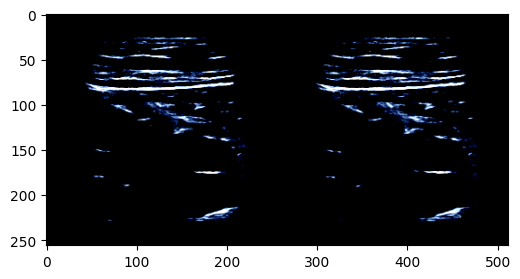

In [9]:
np_clips = clips.detach().cpu().numpy()
print(np_clips.shape)
plt.figure(figsize=(20, 3))
_ = plt.imshow(np.transpose(np_clips[0], (2, 1, 3, 0)).reshape(256, 256 * T, 3))

In [18]:
def forward_target(c, normalize_reps=True):
    B, C, T, H, W = c.size()
    c = c.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
    h = encoder(c)
    h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)
    if normalize_reps:
        h = F.layer_norm(h, (h.size(-1),))
    return h


def forward_actions(z, nsamples, grid_size=0.075, normalize_reps=True, action_repeat=1):

    def make_action_grid(grid_size=grid_size):
        action_samples = []
        for da in np.linspace(-grid_size, grid_size, nsamples):
            for db in np.linspace(-grid_size, grid_size, nsamples):
                for dc in np.linspace(-grid_size, grid_size, nsamples):
                    action_samples += [torch.tensor([da, db, dc, 0, 0, 0], device=z.device, dtype=z.dtype)]
        return torch.stack(action_samples, dim=0).unsqueeze(1)

    # Sample grid of actions
    action_samples = make_action_grid()
    print(f"Sampled grid of actions; num actions = {len(action_samples)}")

    def step_predictor(_z, _a, _s):
        _z = predictor(_z, _a, _s)[:, -tokens_per_frame:]
        if normalize_reps:
            _z = F.layer_norm(_z, (_z.size(-1),))
        _s = compute_new_pose(_s[:, -1:], _a[:, -1:])
        return _z, _s

    # Context frame rep and context pose
    z_hat = z[:, :tokens_per_frame].repeat(int(nsamples**3), 1, 1)  # [S, N, D]
    s_hat = states[:, :1].repeat((int(nsamples**3), 1, 1))  # [S, 1, 7]
    a_hat = action_samples  # [S, 1, 6]

    for _ in range(action_repeat):
        _z, _s = step_predictor(z_hat, a_hat, s_hat)
        z_hat = torch.cat([z_hat, _z], dim=1)
        print(f"s_hat shape: {s_hat.shape}")
        print(f"_s shape: {_s.shape}")
        s_hat = torch.cat([s_hat, _s], dim=1)
        a_hat = torch.cat([a_hat, action_samples], dim=1)

    return z_hat, s_hat, a_hat

def loss_fn(z, h):
    z, h = z[:, -tokens_per_frame:], h[:, -tokens_per_frame:]
    loss = torch.abs(z - h)  # [B, N, D]
    loss = torch.mean(loss, dim=[1, 2])
    return loss.tolist()

In [19]:
# Compute energy for cartesian action grid of size (nsample x nsamples x nsamples)
nsamples = 5
grid_size = 0.075
with torch.no_grad():
    h = forward_target(clips)
    z_hat, s_hat, a_hat = forward_actions(h, nsamples=nsamples, grid_size=grid_size)
    loss = loss_fn(z_hat, h)  # jepa prediction loss

Sampled grid of actions; num actions = 125
s_hat shape: torch.Size([125, 1, 6])
_s shape: torch.Size([125, 1, 7])


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 6 but got size 7 for tensor number 1 in the list.

In [ ]:
# Plot the energy

plot_data = []
for b, v in enumerate(loss):
    plot_data.append((
        a_hat[b, :-1, 0].sum(),
        a_hat[b, :-1, 1].sum(),
        a_hat[b, :-1, 2].sum(),
        v,
    ))

delta_x = [d[0] for d in plot_data]
delta_y = [d[1] for d in plot_data]
delta_z = [d[2] for d in plot_data]
energy = [d[3] for d in plot_data]

gt_x = actions[0, 0, 0]
gt_y = actions[0, 0, 1]
gt_z = actions[0, 0, 2]

# Create the 2D histogram
heatmap, xedges, yedges = np.histogram2d(delta_x, delta_z, weights=energy, bins=nsamples)

# Set axis labels
plt.xlabel("Action Delta x")
plt.ylabel("Action Delta z")
plt.title(f"Energy Landscape")

# Display the heatmap
print(f"Ground truth action (x,y,z) = ({gt_x:.2f},{gt_y:.2f},{gt_z:.2f})")
_ = plt.imshow(heatmap.T, origin="lower", extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis")
_ = plt.colorbar()

In [ ]:
# Compute the optimal action using MPC
from utils.world_model_wrapper import WorldModel

world_model = WorldModel(
    encoder=encoder,
    predictor=predictor,
    tokens_per_frame=tokens_per_frame,
    transform=transform,
    # Doing very few CEM iterations with very few samples just to run efficiently on CPU...
    # ... increase cem_steps and samples for more accurate optimization of energy landscape
    mpc_args={
        "rollout": 2,
        "samples": 25,
        "topk": 10,
        "cem_steps": 2,
        "momentum_mean": 0.15,
        "momentum_mean_gripper": 0.15,
        "momentum_std": 0.75,
        "momentum_std_gripper": 0.15,
        "maxnorm": 0.075,
        "verbose": True
    },
    normalize_reps=True,
    device="cpu"
)

with torch.no_grad():
    h = forward_target(clips)
    z_n, z_goal = h[:, :tokens_per_frame], h[:, -tokens_per_frame:]
    s_n = states[:, :1]
    print(f"Starting planning using Cross-Entropy Method...")
    actions = world_model.infer_next_action(z_n, s_n, z_goal).cpu().numpy()

print(f"Actions returned by planning with CEM (x,y,z) = ({actions[0, 0]:.2f},{actions[0, 1]:.2f} {actions[0, 2]:.2f})")